In [2]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from the_well.data import WellDataModule

DATA_ROOT = "/home/un212/rds/hpc-work/datasets"
DATASET_NAME = "shear_flow"

In [2]:
help(WellDataModule)

Help on class WellDataModule in module the_well.data.datamodule:

class WellDataModule(AbstractDataModule)
 |  WellDataModule(well_base_path: str, well_dataset_name: str, batch_size: int, include_filters: List[str] = [], exclude_filters: List[str] = [], use_normalization: bool = False, normalization_type: Optional[Callable[..., Any]] = None, train_dataset: Callable[..., Any] = <class 'the_well.data.datasets.WellDataset'>, max_rollout_steps: int = 100, n_steps_input: int = 1, n_steps_output: int = 1, min_dt_stride: int = 1, max_dt_stride: int = 1, world_size: int = 1, data_workers: int = 4, rank: int = 1, boundary_return_type: Literal['padding', None] = 'padding', transform: Optional[the_well.data.augmentation.Augmentation] = None, dataset_kws: Optional[Dict[Literal['train', 'val', 'rollout_val', 'test', 'rollout_test'], Dict[str, Any]]] = None, storage_kwargs: Optional[Dict] = None)
 |  
 |  Data module class to yield batches of samples.
 |  
 |  Args:
 |      well_base_path:
 |       

In [7]:
datamodule = WellDataModule(
    DATA_ROOT, 
    DATASET_NAME,
    batch_size = 32
)

test_loader = datamodule.test_dataloader()
batch = next(iter(test_loader))


/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [13]:
print("Batch Keys: ", batch.keys())
print("Input fields: ", batch["input_fields"].shape)
print("Output fields: ", batch["output_fields"].shape)

#Batch size, Time, Input, Output, Chanels


Batch Keys:  dict_keys(['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid'])
Input fields:  torch.Size([32, 1, 256, 512, 4])
Output fields:  torch.Size([32, 1, 256, 512, 4])


In [16]:
metadata = datamodule.train_dataset.metadata
help(metadata)

Help on WellMetadata in module the_well.data.datasets object:

class WellMetadata(builtins.object)
 |  WellMetadata(dataset_name: str, n_spatial_dims: int, spatial_resolution: Tuple[int, ...], scalar_names: List[str], constant_scalar_names: List[str], field_names: Dict[int, List[str]], constant_field_names: Dict[int, List[str]], boundary_condition_types: List[str], n_files: int, n_trajectories_per_file: List[int], n_steps_per_trajectory: List[int], grid_type: str = 'cartesian') -> None
 |  
 |  Dataclass to store metadata for each dataset.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __init__(self, dataset_name: str, n_spatial_dims: int, spatial_resolution: Tuple[int, ...], scalar_names: List[str], constant_scalar_names: List[str], field_names: Dict[int, List[str]], constant_field_names: Dict[int, List[str]], boundary_condition_types: List[str], n_files: int, n_trajectories_per_file: List[int], n_steps_per_trajectory: List[int], grid_

In [17]:
print("Spatial resolution:", metadata.spatial_resolution)
print("Number of trajectories:", metadata.n_trajectories_per_file)
print("Fields:", metadata.field_names)
print("Scalars:", metadata.scalar_names)

Spatial resolution: (256, 512)
Number of trajectories: [32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32]
Fields: {0: ['tracer', 'pressure'], 1: ['velocity_x', 'velocity_y'], 2: []}
Scalars: []


torch.Size([1, 256, 512, 4])


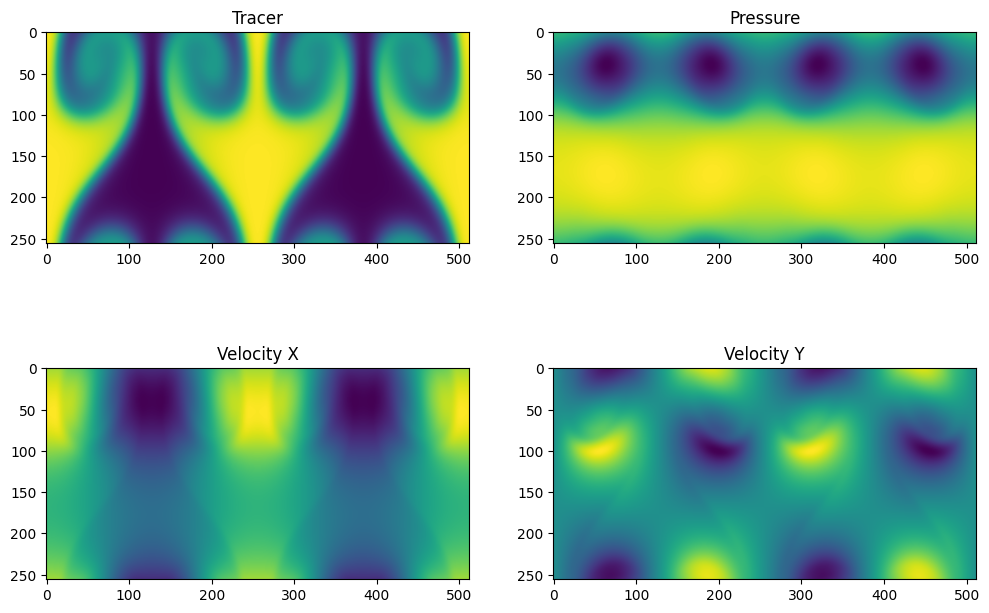

In [52]:
#Get a single sample

data = batch['input_fields'][-1]
field_names = ['Tracer', 'Pressure', 'Velocity X', 'Velocity Y']
print(data.shape)

#or keep the dimensions by using data = batch['input_fields'][0:1]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
for i in range(4):
    ax[i].imshow(data[0,:, :,i], cmap='viridis')
    ax[i].set_title(field_names[i])
plt.show()


In [3]:
#Evolution of tracer over 10 steps


datamodule = WellDataModule(
    DATA_ROOT, 
    DATASET_NAME,
    batch_size=32,
    n_steps_input=50  # Tell it to give you 10 steps of history
)

test_loader = datamodule.test_dataloader()
batch = next(iter(test_loader))

/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x1518fd22b740>
Traceback (most recent call last):
  File "/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib64/python3.11/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib64/python3.11/multiprocessing/popen_fork.py", line 40, in wa

In [6]:
# for i in range(50):
#     plt.imshow(batch['input_fields'][0,i,:,:,0])
#     plt.title(f"Timestep: {i}")
#     plt.show()

In [7]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(batch['input_fields'][0, 0, :, :, 0], cmap='viridis')

def update(frame):
    im.set_array(batch['input_fields'][0, frame, :, :, 0])
    ax.set_title(f"Timestep: {frame}")
    return [im]

# Create animation (10 frames)
ani = FuncAnimation(fig, update, frames=range(50), interval=200)


ani.save('tracer_evolution.gif', writer='pillow')

plt.close() # Prevents showing the final frame as a static plot

# Display the GIF in the notebook
#Image(open('tracer_evolution.gif','rb').read())

***Following and adapting tutorial from https://polymathic-ai.org/the_well/tutorials/dataset/***

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange
from neuralop.models import FNO
from tqdm import tqdm

from the_well.benchmark.metrics import VRMSE
from the_well.data import WellDataset
from the_well.utils.download import well_download

device = "cuda"

In [2]:
base_path = "/home/un212/rds/hpc-work/datasets"  # path/to/storage

dataset = WellDataset(
    well_base_path=base_path,
    well_dataset_name="shear_flow",
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=False,
)

In [4]:
item = dataset[0]
print(list(item.keys()))

print(item["input_fields"].shape)
print(item["output_fields"].shape)


['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid']
torch.Size([4, 256, 512, 4])
torch.Size([1, 256, 512, 4])


In [7]:
print(dataset.metadata.field_names)
field_names = [
    name for group in dataset.metadata.field_names.values() for name in group
]
print(field_names)


{0: ['tracer', 'pressure'], 1: ['velocity_x', 'velocity_y'], 2: []}
['tracer', 'pressure', 'velocity_x', 'velocity_y']


In [14]:
F = dataset.metadata.n_fields
x = dataset[42]["input_fields"]
x = rearrange(x, "T Lx Ly F -> F T Lx Ly")

fig, axs = plt.subplots(F, 4, figsize=(4 * 2.4, F * 1.2))

for field in range(F):
    vmin = np.nanmin(x[field])
    vmax = np.nanmax(x[field])

    axs[field, 0].set_ylabel(f"{field_names[field]}")

    for t in range(4):
        axs[field, t].imshow(
            x[field, t], cmap="RdBu_r", interpolation="none", vmin=vmin, vmax=vmax
        )
        axs[field, t].set_xticks([])
        axs[field, t].set_yticks([])

        axs[0, t].set_title(f"xt_{t}")

plt.tight_layout()
plt.savefig("../figures/shearflow/shear_flow.png")
plt.show()
